# DINOv2

Training DINOv2 model.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### Pretrained DINOv2 with frozen backbone

Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Epoch 1/15 | Train: 29.15% | Val: 38.62% | LR: 0.000100
Epoch 2/15 | Train: 41.05% | Val: 43.09% | LR: 0.000100
Epoch 3/15 | Train: 43.97% | Val: 43.50% | LR: 0.000100
Epoch 4/15 | Train: 45.70% | Val: 45.26% | LR: 0.000100
Epoch 5/15 | Train: 47.32% | Val: 45.12% | LR: 0.000100
Epoch 6/15 | Train: 48.40% | Val: 45.80% | LR: 0.000100
Epoch 7/15 | Train: 49.41% | Val: 45.12% | LR: 0.000100
Epoch 8/15 | Train: 49.90% | Val: 46.34% | LR: 0.000100
Epoch 9/15 | Train: 50.59% | Val: 47.29% | LR: 0.000100
Epoch 10/15 | Train: 50.48% | Val: 48.64% | LR: 0.000100
Epoch 11/15 | Train: 51.15% | Val: 47.15% | LR: 0.000100
Epoch 12/15 | Train: 51.82% | Val: 47.83% | LR: 0.000100
Epoch 13/15 | Train: 51.95% | Val: 48.10% | LR: 0.000100
Epoch 14/15 | Train: 52.90% | Val: 48.78% | LR: 0.000100
Epoch 15/15 | Train: 52.44% | Val: 48.92% | LR: 0.000100


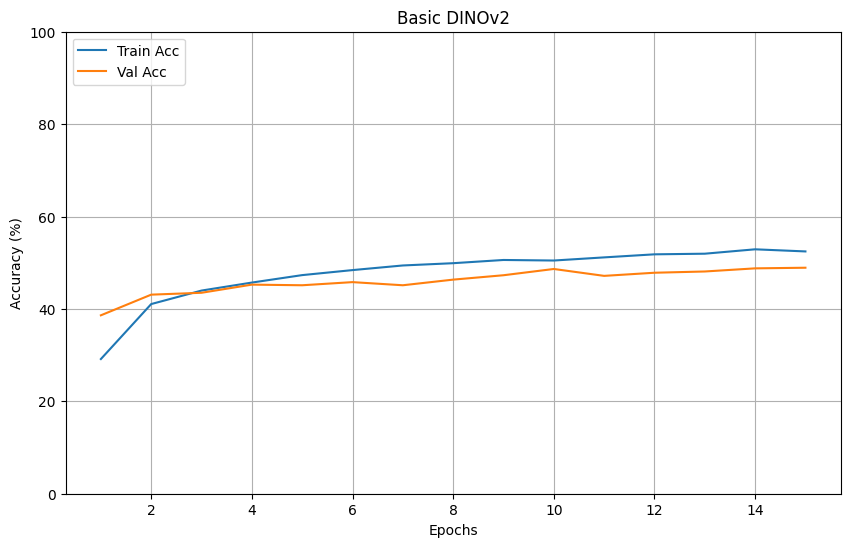


Final Test Accuracy: 48.53%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=15)

plot_history(history, "Basic DINOv2")

test_accuracy = evaluate_model(model, test_loader)

## Pretrained DINOv2 with finetuning last transformer block + head

Using cache found in C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\krist/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Epoch 1/15 | Train: 43.02% | Val: 47.97% | LR: 0.000100
Epoch 2/15 | Train: 52.39% | Val: 54.07% | LR: 0.000100
Epoch 3/15 | Train: 58.79% | Val: 53.66% | LR: 0.000100
Epoch 4/15 | Train: 64.40% | Val: 47.70% | LR: 0.000100
Epoch 5/15 | Train: 70.15% | Val: 50.00% | LR: 0.000100
Epoch 6/15 | Train: 78.27% | Val: 52.30% | LR: 0.000100
Epoch 7/15 | Train: 86.01% | Val: 53.25% | LR: 0.000100
Epoch 8/15 | Train: 92.07% | Val: 52.17% | LR: 0.000100
Epoch 9/15 | Train: 95.20% | Val: 51.76% | LR: 0.000100
Epoch 10/15 | Train: 96.66% | Val: 50.95% | LR: 0.000100
Epoch 11/15 | Train: 98.81% | Val: 55.83% | LR: 0.000100
Epoch 12/15 | Train: 99.00% | Val: 52.30% | LR: 0.000100
Epoch 13/15 | Train: 99.08% | Val: 50.81% | LR: 0.000100
Epoch 14/15 | Train: 96.26% | Val: 51.63% | LR: 0.000100
Epoch 15/15 | Train: 93.67% | Val: 51.36% | LR: 0.000100


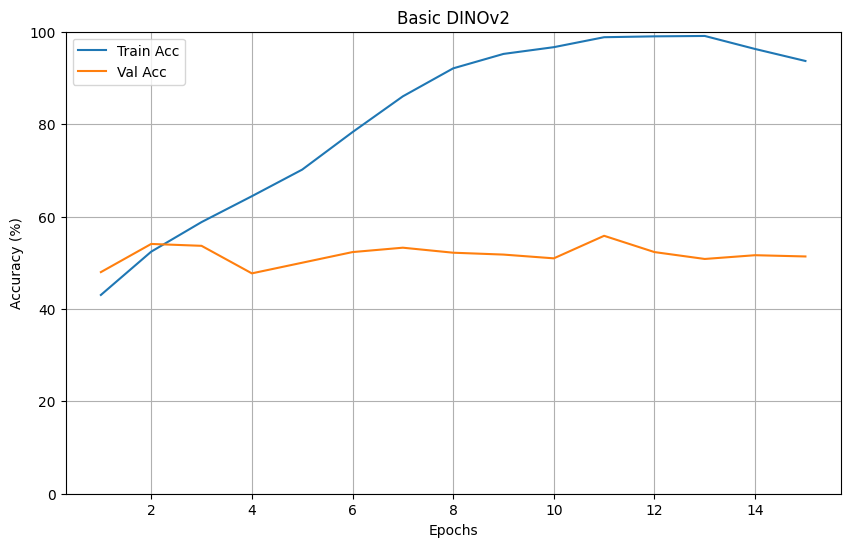


Final Test Accuracy: 51.11%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="dinov2",
    pretrained=True,
    lr = 1e-4,
    dinov2_freeze_backbone=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=15)

plot_history(history, "Basic DINOv2")

test_accuracy = evaluate_model(model, test_loader)